# SLM Dissertation — Analysis Notebook
**Evaluating Small Language Models for Resource-Constrained Local Deployment**
MSc Dissertation — Newcastle University | Supervisor: Dr Tomasz Szydlo

| Section | Content |
|---------|---------|
| 0 | Setup & Data Loading |
| 1 | Capability Analysis (MMLU / ARC / HellaSwag) |
| 2 | Performance Analysis (Latency / Throughput / RAM / TTFT / Energy) |
| 3 | Statistical Tests (Friedman · Kendall's W · Wilcoxon · Bonferroni) |
| 4 | Tool-Calling Analysis |
| 5 | Combined Analysis (Radar · Bubble · Pareto) |
| 6 | Export |

## 0. Setup & Data Loading

In [1]:
import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE        = '..'
CAP_DIR     = os.path.join(BASE, 'results', 'capability')
RUNTIME_CSV = os.path.join(BASE, 'results', 'runtime_results.csv')
SUMMARY_CSV = os.path.join(BASE, 'results', 'summary.csv')
TOOL_SUM    = os.path.join(BASE, 'results', 'tool_calling', 'tool_calling_summary.csv')
TOOL_RES    = os.path.join(BASE, 'results', 'tool_calling', 'tool_calling_results.csv')
FIGURES_DIR = os.path.join(BASE, 'results', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
MODEL_ORDER = ['Qwen2.5 0.5B', 'TinyLlama 1.1B', 'Qwen2 1.5B',
               'Llama3.2 3B', 'Phi-3 3.8B']
OLLAMA_LABELS = {
    'qwen2.5:0.5b':     'Qwen2.5 0.5B',
    'tinyllama:latest': 'TinyLlama 1.1B',
    'qwen2:1.5b':       'Qwen2 1.5B',
    'llama3.2:3b':      'Llama3.2 3B',
    'phi3:latest':      'Phi-3 3.8B',
}
CAP_DIRS = {
    'qwen2.5_0.5b':   'Qwen2.5 0.5B',
    'tinyllama_1.1b': 'TinyLlama 1.1B',
    'qwen2_1.5b':     'Qwen2 1.5B',
    'llama3.2_3b':    'Llama3.2 3B',
    'phi3_3.8b':      'Phi-3 3.8B',
}
PALETTE = {
    'Qwen2.5 0.5B':   '#4C72B0',
    'TinyLlama 1.1B': '#DD8452',
    'Qwen2 1.5B':     '#55A868',
    'Llama3.2 3B':    '#C44E52',
    'Phi-3 3.8B':     '#8172B2',
}
SCENARIO_COLORS = {
    'serial':     '#4C72B0',
    'high_load':  '#DD8452',
    'concurrent': '#C44E52',
}
# lm-eval group-level aggregation keys — excluded from per-subject MMLU scores
MMLU_GROUP_KEYS = {
    'mmlu', 'mmlu_pro', 'mmlu_humanities', 'mmlu_stem',
    'mmlu_social_sciences', 'mmlu_other',
}
WANTED_EXACT = {'arc_challenge', 'hellaswag'}
DPI = 300

def savefig(name):
    plt.savefig(os.path.join(FIGURES_DIR, name), dpi=DPI, bbox_inches='tight')
    print(f'  Saved: {name}')

def reorder(df, col='model'):
    order = {m: i for i, m in enumerate(MODEL_ORDER)}
    df = df.copy()
    df['_ord'] = df[col].map(order).fillna(99)
    return df.sort_values('_ord').drop(columns=['_ord']).reset_index(drop=True)

print('Setup complete.')
print('Figures output:', os.path.abspath(FIGURES_DIR))

Setup complete.
Figures output: E:\DATA\gx498\Desktop\course work\8099\results\figures


In [2]:
# ── 0.1  Load all data ────────────────────────────────────────────────────────

# --- Capability (lm-eval JSON) ---
cap = {}
for subdir, label in CAP_DIRS.items():
    model_path = os.path.join(CAP_DIR, subdir)
    if not os.path.isdir(model_path):
        continue
    # lm-eval saves as results_<timestamp>.json, not results.json
    candidates = glob.glob(os.path.join(model_path, '**', 'results_*.json'),
                           recursive=True)
    if not candidates:
        print(f'[MISSING] {label}')
        continue
    candidates.sort(key=os.path.getmtime, reverse=True)
    with open(candidates[0], encoding='utf-8') as f:
        data = json.load(f)
    scores = {}
    for task, metrics in data.get('results', {}).items():
        is_mmlu = task.startswith('mmlu_') and task not in MMLU_GROUP_KEYS
        if not (is_mmlu or task in WANTED_EXACT):
            continue
        if 'acc_norm,none' in metrics:
            scores[task] = metrics['acc_norm,none']
        elif 'acc,none' in metrics:
            scores[task] = metrics['acc,none']
    cap[label] = scores
    print(f'Capability: {label}  ({len(scores)} tasks)')

# --- Performance ---
raw     = pd.DataFrame()
summary = pd.DataFrame()
if os.path.exists(RUNTIME_CSV):
    raw = pd.read_csv(RUNTIME_CSV)
    raw['model_label'] = raw['model'].map(OLLAMA_LABELS).fillna(raw['model'])
    # Safe bool: avoids "False".astype(bool) == True trap
    raw['_is_outlier'] = raw['is_outlier'].astype(str).str.lower().eq('true')
    print(f'Runtime loaded: {len(raw)} rows')
if os.path.exists(SUMMARY_CSV):
    summary = pd.read_csv(SUMMARY_CSV)
    print(f'Summary loaded: {len(summary)} rows')
    print('Columns:', summary.columns.tolist())

# --- Tool calling ---
tc_summary = pd.DataFrame()
tc_results = pd.DataFrame()
if os.path.exists(TOOL_SUM):
    tc_summary = pd.read_csv(TOOL_SUM)
    tc_summary  = reorder(tc_summary)
    print(f'Tool-calling summary: {len(tc_summary)} models')
if os.path.exists(TOOL_RES):
    tc_results = pd.read_csv(TOOL_RES)
    print(f'Tool-calling results: {len(tc_results)} rows')

Capability: Qwen2.5 0.5B  (12 tasks)
Capability: TinyLlama 1.1B  (12 tasks)
Capability: Qwen2 1.5B  (12 tasks)
Capability: Llama3.2 3B  (12 tasks)
Capability: Phi-3 3.8B  (12 tasks)
Runtime loaded: 2250 rows
Summary loaded: 15 rows
Columns: ['model', 'scenario', 'n_requests', 'latency_mean_ms', 'latency_std_ms', 'latency_p50_ms', 'latency_p90_ms', 'latency_p99_ms', 'ttft_mean_ms', 'decode_speed_mean', 'ram_peak_mean_gb', 'cpu_peak_mean_pct', 'gpu_mem_peak_gb', 'session_net_energy_mean_j', 'session_net_energy_std_j', 'energy_per_tok_mean_j', 'degradation_mean_pct', 'cold_start_ms']
Tool-calling summary: 5 models
Tool-calling results: 165 rows


## 1. Capability Analysis
> **Benchmarks**: MMLU (10 subjects, n=100 each), ARC-Challenge, HellaSwag
> **Setup**: zero-shot, float16, lm-evaluation-harness v0.4

In [3]:
# 1.1  Raw capability scores table
mmlu_tasks = sorted({t for tasks in cap.values()
                     for t in tasks if t.startswith('mmlu_')})

cap_rows = []
for model in MODEL_ORDER:
    if model not in cap:
        continue
    t  = cap[model]
    mv = [t[x] for x in mmlu_tasks if x in t]
    cap_rows.append({
        'Model':         model,
        'MMLU Avg':      round(np.mean(mv), 3) if mv else float('nan'),
        'ARC-Challenge': round(t.get('arc_challenge', float('nan')), 3),
        'HellaSwag':     round(t.get('hellaswag',    float('nan')), 3),
    })

cap_table = pd.DataFrame(cap_rows)
display(cap_table.style
        .set_caption('Table 1: Capability Results (zero-shot accuracy)')
        .format('{:.3f}', subset=['MMLU Avg', 'ARC-Challenge', 'HellaSwag'])
        .background_gradient(cmap='RdYlGn', vmin=0.2, vmax=0.8,
                             subset=['MMLU Avg', 'ARC-Challenge', 'HellaSwag']))

,Model,MMLU Avg,ARC-Challenge,HellaSwag
0,Qwen2.5 0.5B,0.439,0.280,0.520
1,TinyLlama 1.1B,0.252,0.330,0.630
2,Qwen2 1.5B,0.505,0.360,0.620
3,Llama3.2 3B,0.498,0.410,0.670
4,Phi-3 3.8B,0.658,0.610,0.660


  Saved: cap_01_overview.png


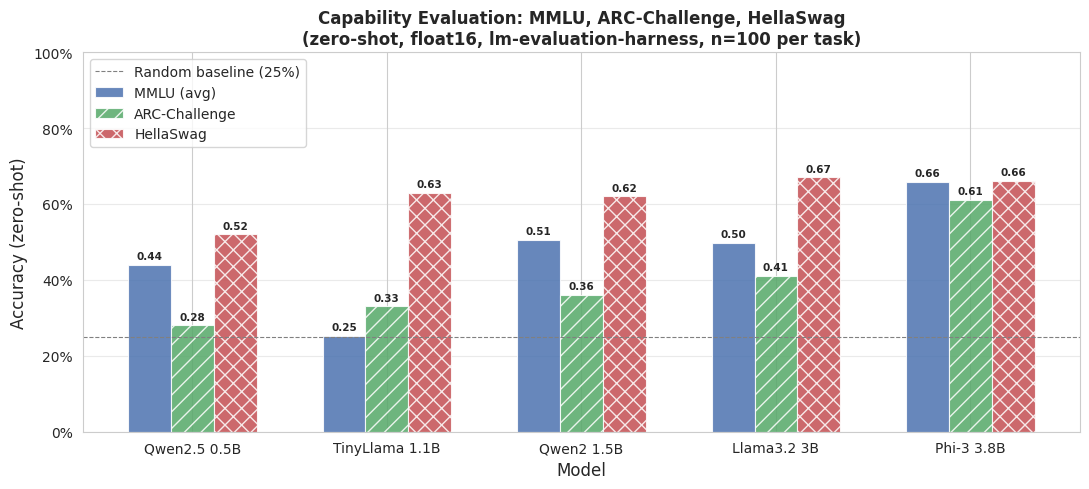

In [4]:
# 1.2  Fig cap_01: Capability overview grouped bar
df_cap     = pd.DataFrame(cap_rows).rename(
    columns={'Model': 'model', 'MMLU Avg': 'MMLU (avg)'})
metrics    = ['MMLU (avg)', 'ARC-Challenge', 'HellaSwag']
bar_colors = ['#4C72B0', '#55A868', '#C44E52']
hatches    = ['', '//', 'xx']
x, width   = np.arange(len(df_cap)), 0.22

fig, ax = plt.subplots(figsize=(11, 5))
for i, (m, c, h) in enumerate(zip(metrics, bar_colors, hatches)):
    bars = ax.bar(x + i * width, df_cap[m], width, label=m,
                  color=c, alpha=0.85, edgecolor='white', linewidth=0.8, hatch=h)
    for bar, v in zip(bars, df_cap[m]):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f'{v:.2f}', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold')
ax.axhline(0.25, color='gray', linestyle='--', linewidth=0.8,
           label='Random baseline (25%)')
ax.set_ylabel('Accuracy (zero-shot)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Capability Evaluation: MMLU, ARC-Challenge, HellaSwag\n'
             '(zero-shot, float16, lm-evaluation-harness, n=100 per task)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(df_cap['model'].tolist(), fontsize=10)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
savefig('cap_01_overview.png')
plt.show()

  Saved: cap_02_mmlu_heatmap.png


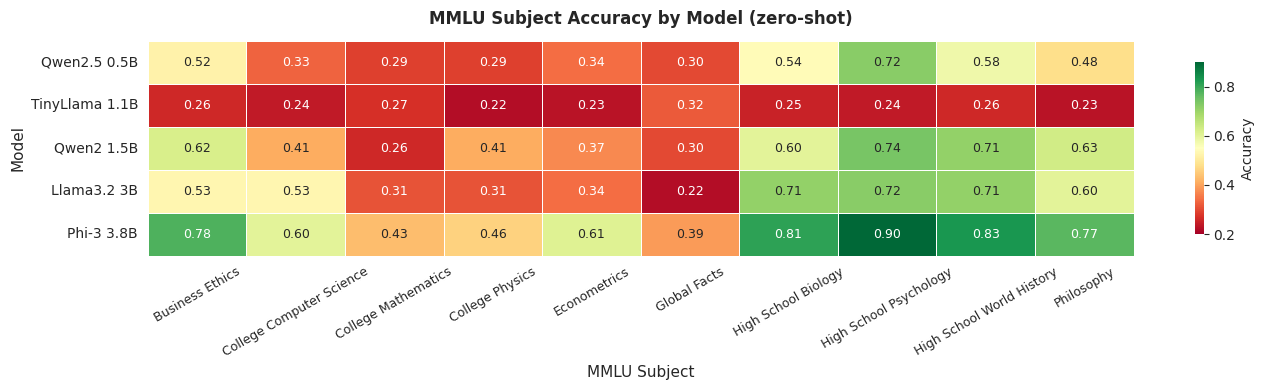

In [5]:
# 1.3  Fig cap_02: MMLU subject heatmap
def tidy(t):
    return t.replace('mmlu_', '').replace('_', ' ').title()

hm_data = {}
for model in MODEL_ORDER:
    if model not in cap:
        continue
    hm_data[model] = {tidy(t): cap[model].get(t, np.nan) for t in mmlu_tasks}

df_mmlu = pd.DataFrame(hm_data).T
df_mmlu = df_mmlu.reindex([m for m in MODEL_ORDER if m in df_mmlu.index])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_mmlu, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.2, vmax=0.9, linewidths=0.5,
            cbar_kws={'label': 'Accuracy', 'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('MMLU Subject Accuracy by Model (zero-shot)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('MMLU Subject', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
savefig('cap_02_mmlu_heatmap.png')
plt.show()

## 2. Performance Analysis
> **Setup**: 3 runs × 50 LDWS prompts per model × 3 scenarios; temp=0, max_tokens=256

In [6]:
# 2.1  Performance summary table (serial scenario)
if not summary.empty:
    serial = reorder(summary[summary['scenario'] == 'serial'].copy())
    show_cols = [c for c in [
        'model', 'latency_mean_ms', 'latency_std_ms', 'latency_p90_ms',
        'latency_p99_ms', 'decode_speed_mean', 'ram_peak_mean_gb',
        'ttft_mean_ms', 'cold_start_ms'
    ] if c in serial.columns]
    display(serial[show_cols].round(2).style
            .set_caption('Table 2: Performance Summary — Serial Scenario')
            .background_gradient(cmap='RdYlGn_r', subset=['latency_mean_ms'], axis=0)
            .background_gradient(cmap='RdYlGn',   subset=['decode_speed_mean'], axis=0))
else:
    print('[SKIP] summary.csv not loaded')

,model,latency_mean_ms,latency_std_ms,latency_p90_ms,latency_p99_ms,decode_speed_mean,ram_peak_mean_gb,ttft_mean_ms,cold_start_ms
0,Qwen2.5 0.5B,1169.250000,353.340000,1444.380000,1488.190000,311.940000,0.690000,17.140000,2629.300000
1,TinyLlama 1.1B,939.490000,346.130000,1297.450000,1355.910000,247.540000,0.480000,19.120000,2649.620000
2,Qwen2 1.5B,1618.170000,627.690000,2227.900000,2272.520000,160.340000,0.720000,26.070000,2934.650000
3,Llama3.2 3B,2947.150000,1061.250000,3908.540000,4011.000000,81.610000,0.870000,39.380000,3705.800000
4,Phi-3 3.8B,3021.240000,1040.310000,3854.510000,4114.930000,76.340000,0.510000,47.050000,2359.230000


  Saved: perf_01_latency.png


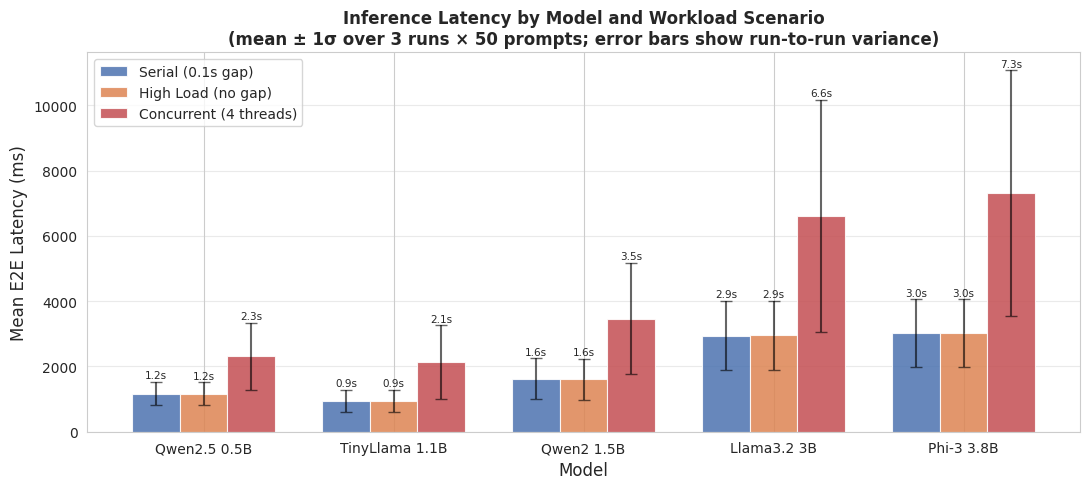

In [7]:
# 2.2  Fig perf_01: Latency grouped bar with error bars (1σ, all 3 scenarios)
if not summary.empty:
    models_present = [m for m in MODEL_ORDER if m in summary['model'].values]
    x, width = np.arange(len(models_present)), 0.25
    scenario_labels = {
        'serial':     'Serial (0.1s gap)',
        'high_load':  'High Load (no gap)',
        'concurrent': 'Concurrent (4 threads)',
    }
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, scenario in enumerate(['serial', 'high_load', 'concurrent']):
        sub = summary[summary['scenario'] == scenario]
        vals, stds = [], []
        for m in models_present:
            row = sub[sub['model'] == m]
            vals.append(row['latency_mean_ms'].values[0] if not row.empty else np.nan)
            stds.append(row['latency_std_ms'].values[0]
                        if (not row.empty and 'latency_std_ms' in row.columns) else 0)
        ax.bar(x + i * width, vals, width,
               label=scenario_labels[scenario],
               color=SCENARIO_COLORS[scenario], alpha=0.85,
               edgecolor='white', linewidth=0.8,
               yerr=stds, capsize=4,
               error_kw={'linewidth': 1.5, 'color': 'black', 'alpha': 0.6})
        for bx, v, sd in zip(x + i * width, vals, stds):
            if not np.isnan(v):
                ax.text(bx, v + sd + 50, f'{v/1000:.1f}s',
                        ha='center', va='bottom', fontsize=7.5)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Mean E2E Latency (ms)', fontsize=12)
    ax.set_title('Inference Latency by Model and Workload Scenario\n'
                 '(mean ± 1σ over 3 runs × 50 prompts; error bars show run-to-run variance)',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(models_present, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    savefig('perf_01_latency.png')
    plt.show()

  Saved: perf_02_distribution.png


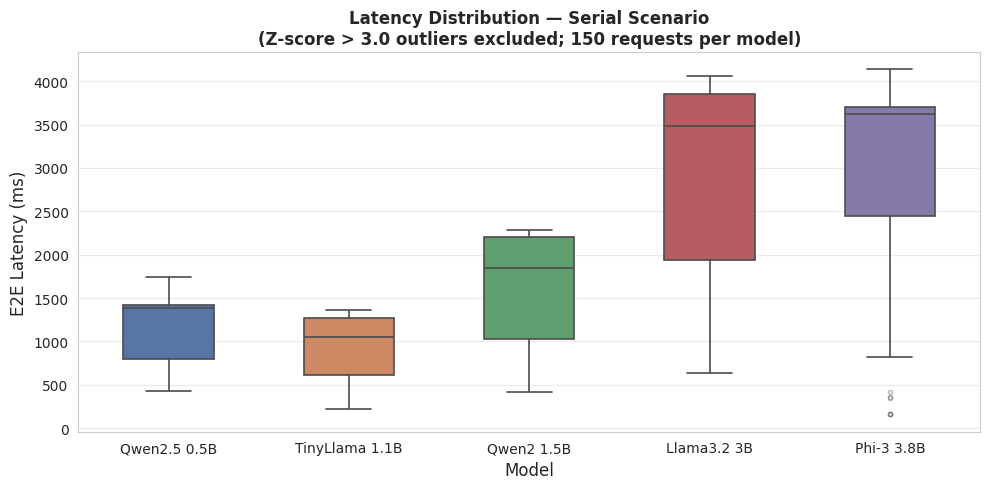

In [8]:
# 2.3  Fig perf_02: Latency distribution boxplot (serial, outliers excluded)
if not raw.empty:
    df_box = raw[(raw['scenario'] == 'serial') & (~raw['_is_outlier'])].copy()
    df_box['model'] = pd.Categorical(
        df_box['model_label'], categories=MODEL_ORDER, ordered=True)
    df_box = df_box.dropna(subset=['model'])
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_box, x='model', y='latency_ms', ax=ax,
                order=MODEL_ORDER, palette=PALETTE, width=0.5,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
                linewidth=1.2)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('E2E Latency (ms)', fontsize=12)
    ax.set_title('Latency Distribution — Serial Scenario\n'
                 '(Z-score > 3.0 outliers excluded; 150 requests per model)',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    savefig('perf_02_distribution.png')
    plt.show()

  Saved: perf_03_07_panel.png


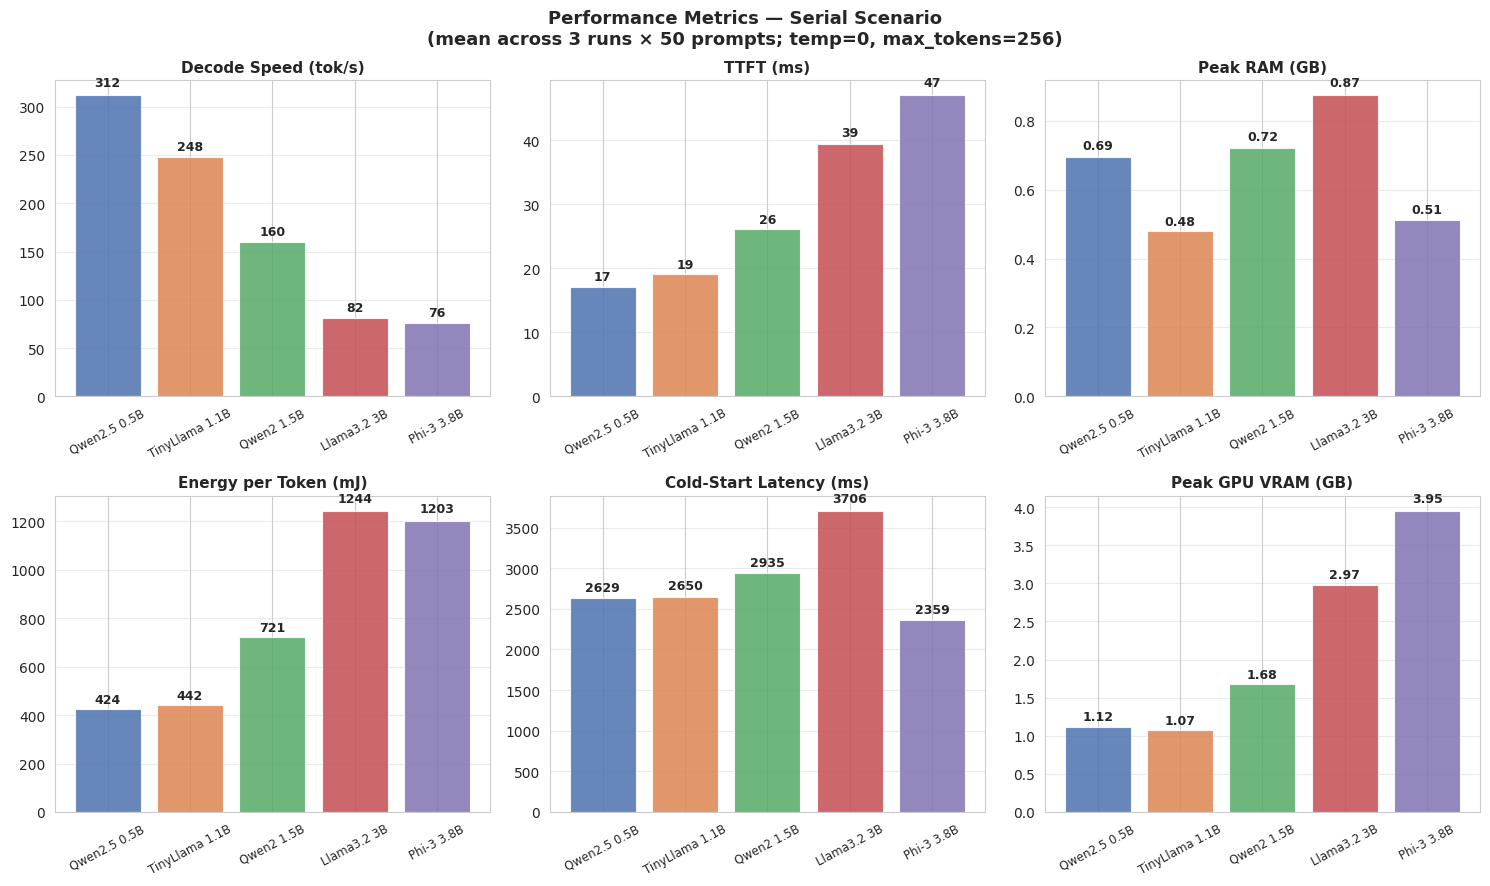

In [9]:
# 2.4  Fig perf_03–07 panel: 6 metrics in 2×3 grid (print-safe layout)
if not summary.empty:
    serial = reorder(summary[summary['scenario'] == 'serial'].copy())

    # Convert J → mJ for legibility (avoids 4-decimal small numbers in chart)
    if 'energy_per_tok_mean_j' in serial.columns:
        serial['energy_per_tok_mean_mj'] = serial['energy_per_tok_mean_j'] * 1000

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes_flat = axes.flatten()

    # 【修改点】：在这里加入了第 6 个指标 GPU VRAM
    specs = [
        ('decode_speed_mean',      'Decode Speed (tok/s)',    '{:.0f}'),
        ('ttft_mean_ms',           'TTFT (ms)',               '{:.0f}'),
        ('ram_peak_mean_gb',       'Peak RAM (GB)',           '{:.2f}'),
        ('energy_per_tok_mean_mj', 'Energy per Token (mJ)',   '{:.0f}'),
        ('cold_start_ms',          'Cold-Start Latency (ms)', '{:.0f}'),
        ('gpu_mem_peak_gb',        'Peak GPU VRAM (GB)',      '{:.2f}'),
    ]

    for ax, (col, ylabel, fmt) in zip(axes_flat, specs):
        if col not in serial.columns or serial[col].fillna(0).sum() == 0:
            ax.set_title(ylabel + '\n[no data]', fontsize=10)
            ax.axis('off')
            continue
        vals = serial[col].fillna(0)
        bars = ax.bar(serial['model'], vals,
                      color=[PALETTE.get(m, '#888') for m in serial['model']],
                      edgecolor='white', linewidth=0.8, alpha=0.85)
        ax.set_title(ylabel, fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=28, labelsize=8.5)
        ax.grid(axis='y', alpha=0.4)

        # Annotate after grid so ylim is stable; guarantee minimum visible offset
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        for bar, v in zip(bars, vals):
            offset = max(v * 0.02, y_range * 0.01)
            ax.text(bar.get_x() + bar.get_width() / 2, v + offset,
                    fmt.format(v), ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

    plt.suptitle('Performance Metrics — Serial Scenario\n'
                 '(mean across 3 runs × 50 prompts; temp=0, max_tokens=256)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('perf_03_07_panel.png')
    plt.show()

> ⚠️ **Energy measurement caveat**
>
> CodeCarbon on Windows 11 cannot access RAPL (Running Average Power Limit)
> hardware counters, which require Linux kernel access. Energy estimates are
> therefore derived from **TDP-based modelling** rather than direct measurement.
> Values should be interpreted as **relative comparisons between models**
> rather than absolute energy consumption figures.
> Cross-validation via `pynvml` GPU power readings is reported in Section 2.6.

  Saved: perf_08_degradation.png


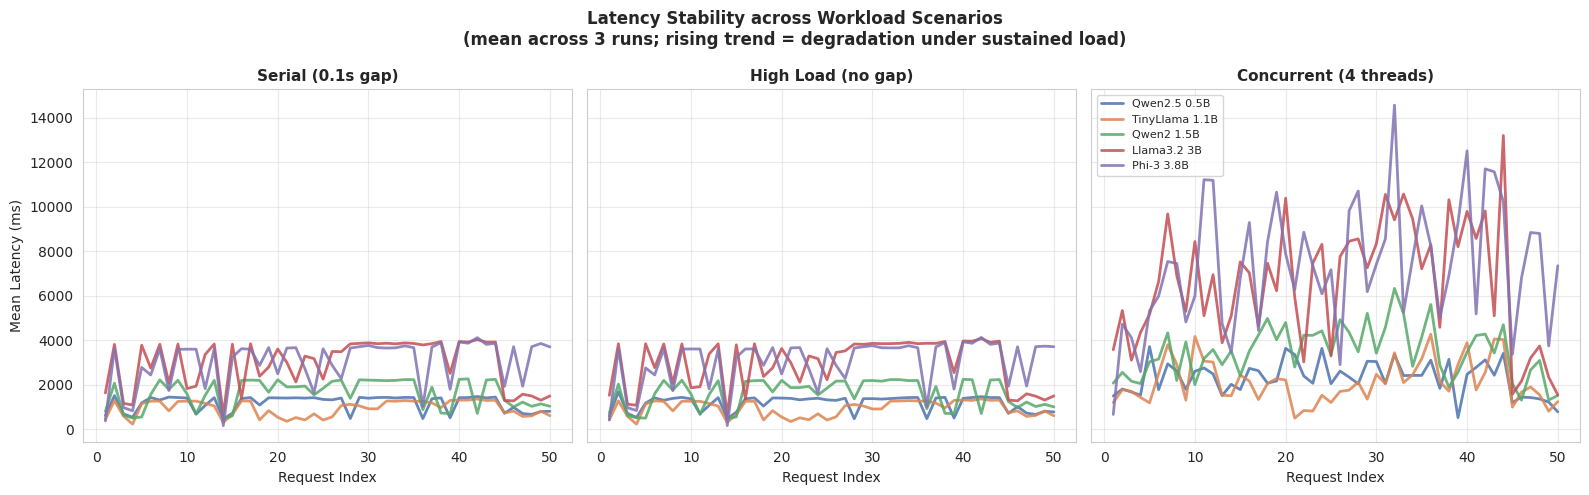

In [10]:
# 2.9  Fig perf_08: Latency degradation — all 3 scenarios as subplots
if not raw.empty and 'request_index' in raw.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    scenarios = ['serial', 'high_load', 'concurrent']
    titles    = ['Serial (0.1s gap)', 'High Load (no gap)', 'Concurrent (4 threads)']
    for ax, scenario, title in zip(axes, scenarios, titles):
        df_deg = raw[(raw['scenario'] == scenario) & (~raw['_is_outlier'])].copy()
        df_deg['model'] = df_deg['model_label']
        grouped = (df_deg.groupby(['model', 'request_index'])['latency_ms']
                   .mean().reset_index())
        for model in MODEL_ORDER:
            sub = grouped[grouped['model'] == model]
            if sub.empty:
                continue
            ax.plot(sub['request_index'], sub['latency_ms'],
                    label=model, color=PALETTE[model], linewidth=2, alpha=0.85)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Request Index', fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel('Mean Latency (ms)', fontsize=10)
        ax.grid(alpha=0.4)
        if ax is axes[2]:
            ax.legend(fontsize=8, loc='upper left')
    fig.suptitle('Latency Stability across Workload Scenarios\n'
                 '(mean across 3 runs; rising trend = degradation under sustained load)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('perf_08_degradation.png')
    plt.show()
else:
    print('[SKIP] raw data or request_index column not available')

In [11]:
# 2.10  Table 2b: Degradation rate summary
if not summary.empty and 'degradation_mean_pct' in summary.columns:
    deg_table = (summary
                 .pivot_table(index='model', columns='scenario',
                              values='degradation_mean_pct', aggfunc='mean')
                 .reindex(MODEL_ORDER)
                 .round(2))
    deg_table.columns = [c.replace('_', ' ').title() for c in deg_table.columns]
    display(deg_table.style
            .set_caption(
                'Table 2b: Latency Degradation Rate by Model and Scenario (%)\n'
                '(degradation = (mean last 10 − mean first 10) / mean first 10 × 100;'
                ' higher = worse stability)')
            .background_gradient(cmap='RdYlGn_r', axis=None)
            .format('{:.1f}%'))
else:
    print('[SKIP] degradation_mean_pct column not found in summary.csv')

,Concurrent,High Load,Serial
model,,,
Qwen2.5 0.5B,49.8%,62.9%,68.7%
TinyLlama 1.1B,43.5%,60.7%,58.8%
Qwen2 1.5B,98.6%,162.3%,155.1%
Llama3.2 3B,74.9%,94.0%,81.1%
Phi-3 3.8B,94.0%,211.6%,209.6%


  Saved: perf_09_percentiles.png


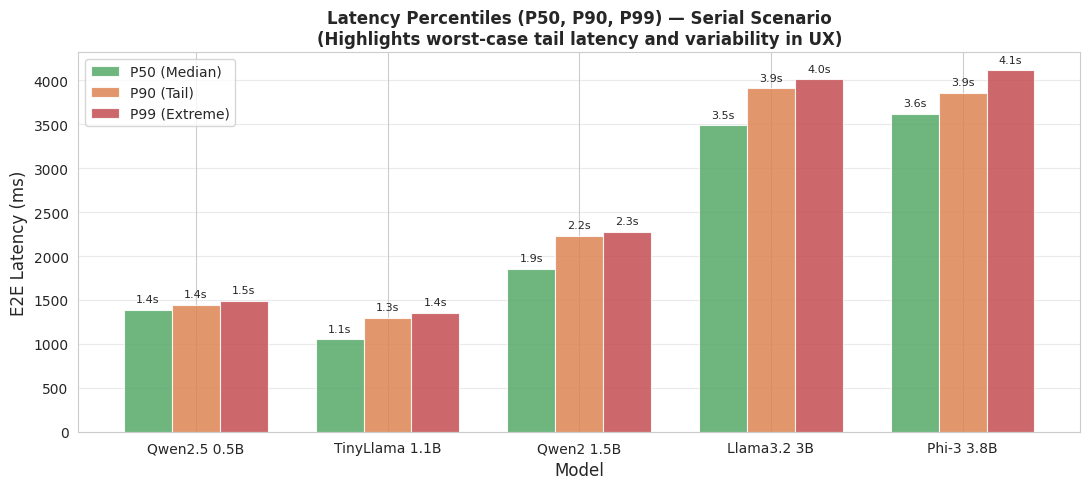

In [12]:
# 2.11  Fig perf_09: P50, P90, P99 Latency percentiles (Serial scenario)
if not summary.empty:
    df_perc = reorder(summary[summary['scenario'] == 'serial'].copy())
    models_pres = df_perc['model'].tolist()
    x, width = np.arange(len(models_pres)), 0.25
    fig, ax = plt.subplots(figsize=(11, 5))
    metrics = [('latency_p50_ms', 'P50 (Median)', '#55A868'),
               ('latency_p90_ms', 'P90 (Tail)',   '#DD8452'),
               ('latency_p99_ms', 'P99 (Extreme)','#C44E52')]
    bars_all = []
    for i, (col, label, color) in enumerate(metrics):
        if col in df_perc.columns:
            bars = ax.bar(x + i * width, df_perc[col], width, label=label,
                          color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
            bars_all.append((bars, df_perc[col].values))
    # Annotate after all bars are drawn so ylim is final
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bars, vals in bars_all:
        for bar, v in zip(bars, vals):
            if not pd.isna(v) and v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, v + y_range * 0.015,
                        f'{v/1000:.1f}s', ha='center', va='bottom', fontsize=8)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('E2E Latency (ms)', fontsize=12)
    ax.set_title('Latency Percentiles (P50, P90, P99) — Serial Scenario\n'
                 '(Highlights worst-case tail latency and variability in UX)',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(models_pres, fontsize=10)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    savefig('perf_09_percentiles.png')
    plt.show()
else:
    print('[SKIP] summary.csv not available')

  Saved: perf_10_cold_start.png


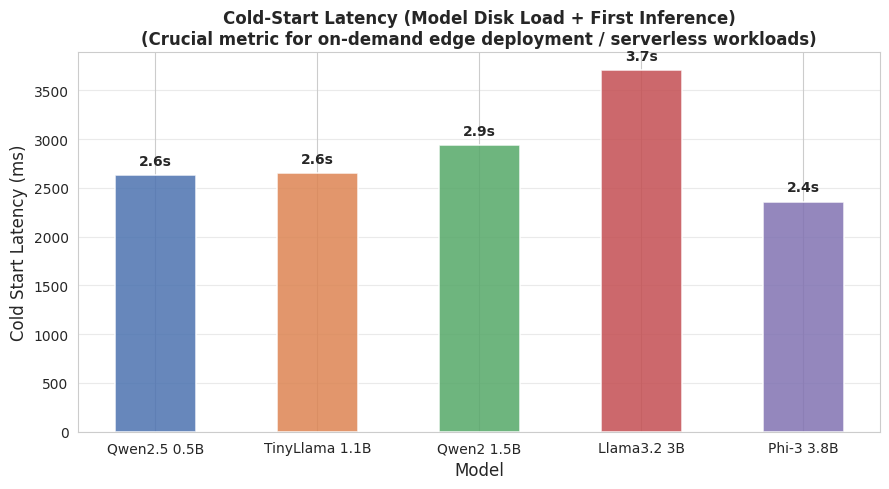

In [13]:
# 2.12  Fig perf_10: Cold Start Latency
if not summary.empty:
    # Cold start is largely scenario-independent; use serial representation
    df_cold = reorder(summary[summary['scenario'] == 'serial'].copy())
    if 'cold_start_ms' in df_cold.columns and df_cold['cold_start_ms'].sum() > 0:
        fig, ax = plt.subplots(figsize=(9, 5))
        vals = df_cold['cold_start_ms'].values
        models_pres = df_cold['model'].tolist()

        bars = ax.bar(models_pres, vals,
                      color=[PALETTE.get(m, '#888') for m in models_pres],
                      edgecolor='white', linewidth=1.2, alpha=0.85, width=0.5)

        for bar, v in zip(bars, vals):
            if v > 0:
                y_offset = max(v * 0.02, ax.get_ylim()[1] * 0.02)
                ax.text(bar.get_x() + bar.get_width()/2, v + y_offset,
                        f'{v/1000:.1f}s', ha='center', va='bottom',
                        fontsize=10, fontweight='bold')

        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Cold Start Latency (ms)', fontsize=12)
        ax.set_title('Cold-Start Latency (Model Disk Load + First Inference)\n'
                     '(Crucial metric for on-demand edge deployment / serverless workloads)',
                     fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.4)
        plt.tight_layout()
        savefig('perf_10_cold_start.png')
        plt.show()
    else:
        print('[SKIP] cold_start_ms not populated or all zero')

  Saved: perf_11_concurrency_penalty.png


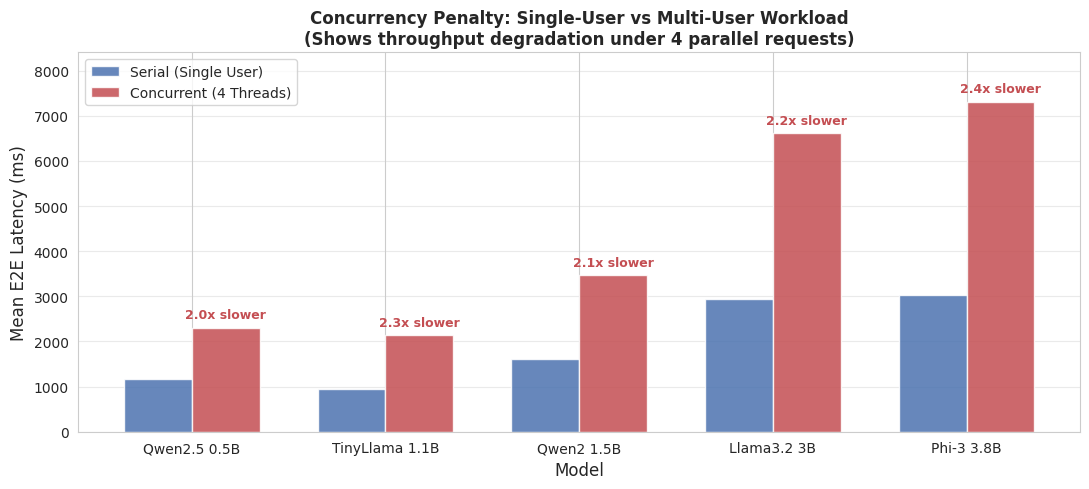

In [14]:
# 2.13  Fig perf_11: Concurrency Penalty (Serial vs Concurrent)
if not summary.empty:
    df_ser = summary[summary['scenario'] == 'serial'].set_index('model')
    df_con = summary[summary['scenario'] == 'concurrent'].set_index('model')
    common_models = [m for m in MODEL_ORDER if m in df_ser.index and m in df_con.index]
    if common_models:
        x, width = np.arange(len(common_models)), 0.35
        vals_ser = [df_ser.loc[m, 'latency_mean_ms'] for m in common_models]
        vals_con = [df_con.loc[m, 'latency_mean_ms'] for m in common_models]
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.bar(x - width/2, vals_ser, width, label='Serial (Single User)',
               color=SCENARIO_COLORS['serial'], alpha=0.85, edgecolor='white')
        ax.bar(x + width/2, vals_con, width, label='Concurrent (4 Threads)',
               color=SCENARIO_COLORS['concurrent'], alpha=0.85, edgecolor='white')
        # Reserve 15% headroom above the tallest bar for the multiplier labels
        y_max_data = max(max(vals_ser), max(vals_con))
        ax.set_ylim(0, y_max_data * 1.15)
        y_offset = y_max_data * 0.02
        for bx, vs, vc in zip(x, vals_ser, vals_con):
            if vc > 0 and vs > 0:
                multiplier = vc / vs
                ax.text(bx + width/2, vc + y_offset,
                        f'{multiplier:.1f}x slower', ha='center', va='bottom',
                        fontsize=9, fontweight='bold', color='#C44E52')
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Mean E2E Latency (ms)', fontsize=12)
        ax.set_title('Concurrency Penalty: Single-User vs Multi-User Workload\n'
                     '(Shows throughput degradation under 4 parallel requests)',
                     fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(common_models, fontsize=10)
        ax.legend(fontsize=10, loc='upper left')
        ax.grid(axis='y', alpha=0.4)
        plt.tight_layout()
        savefig('perf_11_concurrency_penalty.png')
        plt.show()
    else:
        print('[SKIP] Missing data for serial or concurrent scenarios')

## 3. Statistical Tests

Tests H₀: all five models have identical latency distributions.

**Paired design**: each prompt runs on all 5 models → natural pairing.
`pivot_table(aggfunc='mean')` collapses 3 runs to a per-prompt mean;
`dropna()` retains only prompts where every model has a valid value.

1. **Friedman test** — non-parametric k-sample paired test (χ²)
2. **Kendall's W** — effect size: W = χ² / (n × (k−1)), range [0, 1]
3. **Pairwise Wilcoxon** — signed-rank test on aligned prompt pairs
4. **Bonferroni correction** — controls FWER across C(5,2)=10 pairs per scenario

In [15]:
# 3.1  Friedman test + Kendall's W (all 3 scenarios)
results_stats = {}   # populated here; referenced by Section 3.2

for scenario in ['serial', 'high_load', 'concurrent']:
    print(f"\n{'='*60}")
    print(f"  SCENARIO: {scenario.upper()}")
    print(f"{'='*60}")

    if raw.empty:
        print('  [SKIP] raw data not loaded')
        continue

    df_s = raw[(raw['scenario'] == scenario) & (~raw['_is_outlier'])].copy()
    df_s['model'] = df_s['model_label']
    idx_col = 'prompt_index' if 'prompt_index' in df_s.columns else 'request_index'

    pivot = (df_s.pivot_table(
                 index=idx_col, columns='model',
                 values='latency_ms', aggfunc='mean')
             .dropna())

    models_in_pivot = [m for m in MODEL_ORDER if m in pivot.columns]
    if len(models_in_pivot) < 2:
        print('  [SKIP] fewer than 2 models with complete data')
        continue

    groups    = [pivot[m].values for m in models_in_pivot]
    n_prompts = len(pivot)
    k_models  = len(groups)
    chi2, p   = stats.friedmanchisquare(*groups)
    W         = chi2 / (n_prompts * (k_models - 1))
    w_label   = ('negligible' if W < 0.1 else 'small' if W < 0.3
                 else 'moderate' if W < 0.5 else 'large')
    sig       = ('***' if p < 0.001 else '**' if p < 0.01
                 else '*' if p < 0.05 else 'n.s.')

    print(f"  Aligned prompts  n  = {n_prompts}")
    print(f"  Models           k  = {k_models}  {models_in_pivot}")
    print(f"  Friedman χ²         = {chi2:.4f}")
    print(f"  p-value             = {p:.6f}  {sig}")
    print(f"  Kendall's W         = {W:.4f}  [{w_label} effect size]")

    results_stats[scenario] = {
        'n': n_prompts, 'k': k_models,
        'chi2': chi2, 'p': p, 'W': W, 'sig': sig,
        'pivot': pivot, 'models': models_in_pivot,
    }

stat_rows = [
    {'Scenario':     s.replace('_', ' ').title(),
     'n (prompts)':  r['n'],
     'Friedman χ²':  round(r['chi2'], 4),
     'p-value':      round(r['p'],    6),
     'Sig.':         r['sig'],
     "Kendall's W":  round(r['W'],    4)}
    for s, r in results_stats.items()
]
if stat_rows:
    display(pd.DataFrame(stat_rows).style
            .set_caption('Table 3: Friedman Test Summary (all scenarios)'))


  SCENARIO: SERIAL
  Aligned prompts  n  = 50
  Models           k  = 5  ['Qwen2.5 0.5B', 'TinyLlama 1.1B', 'Qwen2 1.5B', 'Llama3.2 3B', 'Phi-3 3.8B']
  Friedman χ²         = 155.2960
  p-value             = 0.000000  ***
  Kendall's W         = 0.7765  [large effect size]

  SCENARIO: HIGH_LOAD
  Aligned prompts  n  = 50
  Models           k  = 5  ['Qwen2.5 0.5B', 'TinyLlama 1.1B', 'Qwen2 1.5B', 'Llama3.2 3B', 'Phi-3 3.8B']
  Friedman χ²         = 154.1120
  p-value             = 0.000000  ***
  Kendall's W         = 0.7706  [large effect size]

  SCENARIO: CONCURRENT
  Aligned prompts  n  = 50
  Models           k  = 5  ['Qwen2.5 0.5B', 'TinyLlama 1.1B', 'Qwen2 1.5B', 'Llama3.2 3B', 'Phi-3 3.8B']
  Friedman χ²         = 153.9680
  p-value             = 0.000000  ***
  Kendall's W         = 0.7698  [large effect size]


,Scenario,n (prompts),Friedman χ²,p-value,Sig.,Kendall's W
0,Serial,50,155.296000,0.000000,***,0.776500
1,High Load,50,154.112000,0.000000,***,0.770600
2,Concurrent,50,153.968000,0.000000,***,0.769800


In [16]:
# 3.2  Pairwise Wilcoxon signed-rank + Bonferroni correction
# ── Guard: requires Section 3.1 to have populated results_stats ──────────────
if 'results_stats' not in dir() or not results_stats:
    print('[SKIP] results_stats is empty — run Section 3.1 first')
else:
    all_pairs = []

    for scenario, res in results_stats.items():
        pivot  = res['pivot']
        models = res['models']

        # Diagnostic: warn if concurrent scenario lost many prompts after dropna
        n_aligned = len(pivot)
        print(f"  {scenario}: {n_aligned} aligned prompts used for Wilcoxon", end='')
        if scenario == 'concurrent' and n_aligned < 30:
            print(f"  ⚠️  [WARNING] only {n_aligned} paired prompts — "
                  f"concurrent scheduling may cause asymmetric request_index distribution")
        else:
            print()

        pairs = []
        for i, m1 in enumerate(models):
            for m2 in models[i + 1:]:
                g1, g2 = pivot[m1].values, pivot[m2].values
                _, p_raw = stats.wilcoxon(g1, g2, alternative='two-sided')
                median_diff = float(np.median(g1 - g2))
                pairs.append({'scenario':      scenario,
                              'Model A':       m1,
                              'Model B':       m2,
                              'median_diff_ms': round(median_diff, 1),
                              'p (raw)':       p_raw})

        if pairs:
            df_p = pd.DataFrame(pairs)
            _, p_corr, _, _ = multipletests(
                df_p['p (raw)'], alpha=0.05, method='bonferroni')
            df_p['p (Bonferroni)'] = p_corr
            df_p['Sig.'] = ['***' if p < 0.001 else '**' if p < 0.01
                            else '*' if p < 0.05 else 'n.s.' for p in p_corr]
            all_pairs.append(df_p)

    df_all_pairs = (pd.concat(all_pairs, ignore_index=True)
                    if all_pairs else pd.DataFrame())

    if not df_all_pairs.empty:
        out_path = os.path.join(BASE, 'results', 'statistical_tests.csv')
        df_all_pairs.to_csv(out_path, index=False)
        print(f'\nstatistical_tests.csv  →  {os.path.abspath(out_path)}\n')

        letters = {'serial': 'a', 'high_load': 'b', 'concurrent': 'c'}
        for scenario in ['serial', 'high_load', 'concurrent']:
            sub = df_all_pairs[df_all_pairs['scenario'] == scenario].copy()
            if sub.empty:
                continue
            sub['p (raw)']        = sub['p (raw)'].map('{:.6f}'.format)
            sub['p (Bonferroni)'] = sub['p (Bonferroni)'].map('{:.6f}'.format)
            scen_label = scenario.replace('_', ' ').title()
            display(sub[['Model A', 'Model B', 'median_diff_ms',
                          'p (raw)', 'p (Bonferroni)', 'Sig.']]
                    .style
                    .set_caption(
                        f'Table 3{letters[scenario]}: Pairwise Wilcoxon + Bonferroni'
                        f' — {scen_label}  '
                        f'(median_diff_ms > 0 means Model A slower)')
                    .apply(lambda col: [
                        'background-color: #d4edda; font-weight: bold'
                        if v in ('*', '**', '***') else ''
                        for v in col], subset=['Sig.']))
    else:
        print('[SKIP] No pairwise results produced')

  serial: 50 aligned prompts used for Wilcoxon
  high_load: 50 aligned prompts used for Wilcoxon
  concurrent: 50 aligned prompts used for Wilcoxon

statistical_tests.csv  →  E:\DATA\gx498\Desktop\course work\8099\results\statistical_tests.csv



,Model A,Model B,median_diff_ms,p (raw),p (Bonferroni),Sig.
0,Qwen2.5 0.5B,TinyLlama 1.1B,163.000000,0.000002,0.000022,***
1,Qwen2.5 0.5B,Qwen2 1.5B,-517.000000,0.000000,0.000000,***
2,Qwen2.5 0.5B,Llama3.2 3B,-2185.200000,0.000000,0.000000,***
3,Qwen2.5 0.5B,Phi-3 3.8B,-2239.000000,0.000000,0.000000,***
4,TinyLlama 1.1B,Qwen2 1.5B,-884.000000,0.000000,0.000000,***
5,TinyLlama 1.1B,Llama3.2 3B,-2543.900000,0.000000,0.000000,***
6,TinyLlama 1.1B,Phi-3 3.8B,-2389.700000,0.000000,0.000000,***
7,Qwen2 1.5B,Llama3.2 3B,-1611.800000,0.000000,0.000000,***
8,Qwen2 1.5B,Phi-3 3.8B,-1468.200000,0.000000,0.000000,***
9,Llama3.2 3B,Phi-3 3.8B,176.400000,0.437568,1.000000,n.s.


,Model A,Model B,median_diff_ms,p (raw),p (Bonferroni),Sig.
10,Qwen2.5 0.5B,TinyLlama 1.1B,154.800000,0.000002,0.000022,***
11,Qwen2.5 0.5B,Qwen2 1.5B,-523.500000,0.000000,0.000000,***
12,Qwen2.5 0.5B,Llama3.2 3B,-2153.600000,0.000000,0.000000,***
13,Qwen2.5 0.5B,Phi-3 3.8B,-2247.000000,0.000000,0.000000,***
14,TinyLlama 1.1B,Qwen2 1.5B,-870.600000,0.000000,0.000000,***
15,TinyLlama 1.1B,Llama3.2 3B,-2573.500000,0.000000,0.000000,***
16,TinyLlama 1.1B,Phi-3 3.8B,-2388.800000,0.000000,0.000000,***
17,Qwen2 1.5B,Llama3.2 3B,-1622.600000,0.000000,0.000000,***
18,Qwen2 1.5B,Phi-3 3.8B,-1487.000000,0.000000,0.000000,***
19,Llama3.2 3B,Phi-3 3.8B,169.000000,0.426296,1.000000,n.s.


,Model A,Model B,median_diff_ms,p (raw),p (Bonferroni),Sig.
20,Qwen2.5 0.5B,TinyLlama 1.1B,22.400000,0.377673,1.000000,n.s.
21,Qwen2.5 0.5B,Qwen2 1.5B,-1200.900000,0.000000,0.000000,***
22,Qwen2.5 0.5B,Llama3.2 3B,-4372.600000,0.000000,0.000000,***
23,Qwen2.5 0.5B,Phi-3 3.8B,-4922.800000,0.000000,0.000000,***
24,TinyLlama 1.1B,Qwen2 1.5B,-1191.800000,0.000000,0.000000,***
25,TinyLlama 1.1B,Llama3.2 3B,-4091.600000,0.000000,0.000000,***
26,TinyLlama 1.1B,Phi-3 3.8B,-5160.600000,0.000000,0.000000,***
27,Qwen2 1.5B,Llama3.2 3B,-2952.100000,0.000000,0.000000,***
28,Qwen2 1.5B,Phi-3 3.8B,-3893.400000,0.000000,0.000000,***
29,Llama3.2 3B,Phi-3 3.8B,-381.200000,0.207960,1.000000,n.s.


## 4. Tool-Calling Analysis
> **Setup**: 33 cases (simple_call / tool_selection / no_call / complex_params); temp=0, seed=42

In [17]:
# 4.1  Tool-calling results table
if not tc_summary.empty:
    show_cols = [c for c in [
        'model', 'overall_accuracy', 'tool_selection_acc',
        'param_accuracy', 'no_call_accuracy',
        'simple_call_acc', 'tool_selection_cat_acc', 'complex_params_acc'
    ] if c in tc_summary.columns]
    display(tc_summary[show_cols].round(3).style
            .set_caption('Table 4: Tool-Calling Evaluation Results (33 cases)')
            .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=0,
                                  subset=[c for c in show_cols if c != 'model']))
else:
    print('[SKIP] Tool-calling summary not loaded')

,model,overall_accuracy,tool_selection_acc,param_accuracy,no_call_accuracy,simple_call_acc,tool_selection_cat_acc,complex_params_acc
0,Qwen2.5 0.5B,0.606000,0.680000,0.560000,0.750000,0.700000,0.600000,0.200000
1,TinyLlama 1.1B,0.242000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
2,Qwen2 1.5B,0.242000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
3,Llama3.2 3B,0.727000,1.000000,0.960000,0.000000,1.000000,0.900000,1.000000
4,Phi-3 3.8B,0.242000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000


  Saved: tool_01_heatmap.png


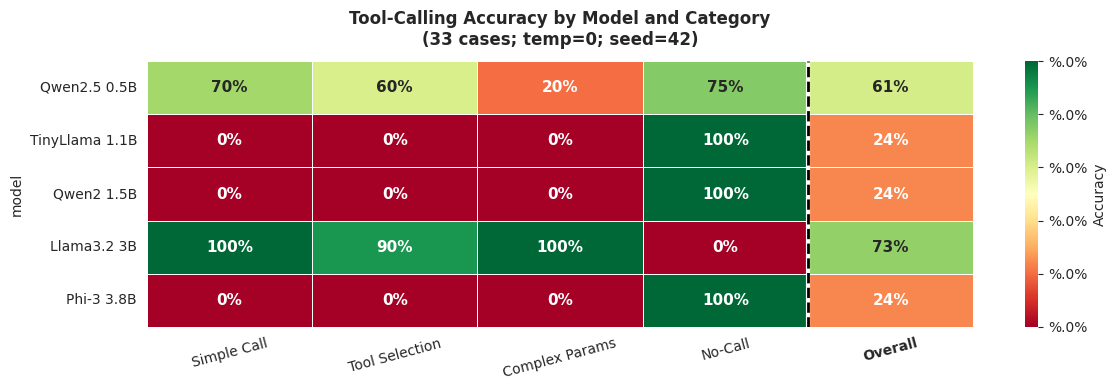

In [18]:
if not tc_summary.empty:
    df_tc   = reorder(tc_summary.copy())
    cat_map = {
        'simple_call_acc':        'Simple Call',
        'tool_selection_cat_acc': 'Tool Selection',
        'complex_params_acc':     'Complex Params',
        'no_call_accuracy':       'No-Call',
        'overall_accuracy':       'Overall',
    }
    avail  = {c: v for c, v in cat_map.items() if c in df_tc.columns}
    matrix = df_tc.set_index('model')[list(avail.keys())]
    matrix.columns = list(avail.values())
    matrix = matrix.reindex([m for m in MODEL_ORDER if m in matrix.index])

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.0%', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'label': 'Accuracy', 'format': '%.0%'},
                annot_kws={'size': 11, 'weight': 'bold'})

    # Overall列加粗竖线分隔
    n_cols = len(matrix.columns)
    ax.axvline(x=n_cols - 1, color='white', linewidth=3)
    ax.axvline(x=n_cols - 1, color='black', linewidth=2, linestyle='--')

    # Overall列标签加粗
    labels = ax.get_xticklabels()
    for label in labels:
        if label.get_text() == 'Overall':
            label.set_fontweight('bold')

    ax.set_title('Tool-Calling Accuracy by Model and Category\n'
                 '(33 cases; temp=0; seed=42)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=15, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)
    plt.tight_layout()
    savefig('tool_01_heatmap.png')
    plt.show()

  Saved: tool_02_overview.png


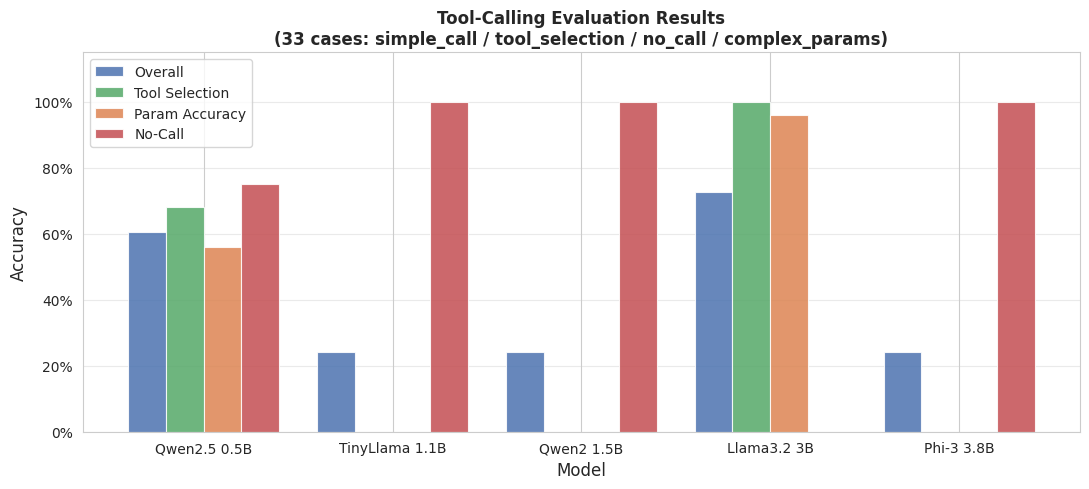

In [19]:
# 4.3  Fig tool_02: Tool-calling overview grouped bar
if not tc_summary.empty:
    df_tc       = reorder(tc_summary.copy())
    metrics_tc  = {'overall_accuracy':   'Overall',
                   'tool_selection_acc': 'Tool Selection',
                   'param_accuracy':     'Param Accuracy',
                   'no_call_accuracy':   'No-Call'}
    tc_colors   = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
    models_pres = [m for m in MODEL_ORDER if m in df_tc['model'].values]
    x, width    = np.arange(len(models_pres)), 0.2
    fig, ax     = plt.subplots(figsize=(11, 5))
    for i, (col, label) in enumerate(metrics_tc.items()):
        if col not in df_tc.columns:
            continue
        vals = [df_tc[df_tc['model'] == m][col].values[0]
                if not df_tc[df_tc['model'] == m].empty else np.nan
                for m in models_pres]
        ax.bar(x + i * width, vals, width, label=label,
               color=tc_colors[i], alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Tool-Calling Evaluation Results\n'
                 '(33 cases: simple_call / tool_selection / no_call / complex_params)',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(models_pres, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    savefig('tool_02_overview.png')
    plt.show()

## 5. Combined Analysis
Cross-dimensional integration of capability, performance, and tool-calling.

In [20]:
# 5.0  Build combined table (shared by all figures in this section)
comb_rows = []
for model in MODEL_ORDER:
    row = {'model': model}
    if model in cap:
        t  = cap[model]
        mv = [t[x] for x in mmlu_tasks if x in t]
        row['mmlu_avg']  = round(np.mean(mv), 3) if mv else np.nan
        row['arc']       = round(t.get('arc_challenge', np.nan), 3)
        row['hellaswag'] = round(t.get('hellaswag',    np.nan), 3)
    if not summary.empty:
        sub = summary[(summary['scenario'] == 'serial') &
                      (summary['model'] == model)]
        if not sub.empty:
            for col in ['latency_mean_ms', 'latency_std_ms', 'latency_p90_ms',
                        'decode_speed_mean', 'ram_peak_mean_gb', 'ttft_mean_ms',
                        'cold_start_ms', 'energy_per_tok_mean_j',
                        'degradation_mean_pct']:
                if col in sub.columns:
                    row[col] = sub[col].values[0]
    if not tc_summary.empty:
        sub = tc_summary[tc_summary['model'] == model]
        if not sub.empty:
            for src, dst in [('overall_accuracy',   'tool_overall'),
                              ('tool_selection_acc', 'tool_selection_acc'),
                              ('param_accuracy',     'tool_param_acc'),
                              ('no_call_accuracy',   'tool_no_call_acc')]:
                if src in sub.columns:
                    row[dst] = sub[src].values[0]
    comb_rows.append(row)

combined = pd.DataFrame(comb_rows)

# Readable latency column "mean ± std" (string, for display only)
if 'latency_std_ms' in combined.columns:
    combined['latency (ms)'] = combined.apply(
        lambda r: f"{r['latency_mean_ms']:.0f} ± {r['latency_std_ms']:.0f}"
        if not pd.isna(r.get('latency_mean_ms')) else '—', axis=1)

show_cols = [c for c in ['model', 'mmlu_avg', 'arc', 'hellaswag',
                          'latency (ms)', 'decode_speed_mean',
                          'ram_peak_mean_gb', 'tool_overall']
             if c in combined.columns]

styler = combined[show_cols].style.set_caption(
    'Table 5: Combined Results Summary — Serial Scenario\n'
    '(latency shown as mean ± 1σ across 3 runs × 50 prompts)')

cap_grad = [c for c in ['mmlu_avg', 'arc', 'hellaswag'] if c in combined.columns]
if cap_grad:
    styler = styler.background_gradient(
        cmap='RdYlGn', subset=cap_grad, vmin=0.2, vmax=0.8)

# Latency: string column; use gmap to apply numeric colour mapping (pandas >= 1.3)
if 'latency (ms)' in show_cols and 'latency_mean_ms' in combined.columns:
    lat_vals = combined['latency_mean_ms'].values
    finite   = lat_vals[~np.isnan(lat_vals)]
    try:
        styler = styler.background_gradient(
            cmap='RdYlGn_r', subset=['latency (ms)'],
            gmap=lat_vals,
            vmin=float(finite.min()), vmax=float(finite.max()))
    except TypeError:
        pass   # pandas < 1.3: no gmap support — display without colour

if 'decode_speed_mean' in combined.columns:
    styler = styler.background_gradient(
        cmap='RdYlGn', subset=['decode_speed_mean'], vmin=0)
if 'tool_overall' in combined.columns:
    styler = styler.background_gradient(
        cmap='RdYlGn', subset=['tool_overall'], vmin=0, vmax=1)

display(styler)

,model,mmlu_avg,arc,hellaswag,latency (ms),decode_speed_mean,ram_peak_mean_gb,tool_overall
0,Qwen2.5 0.5B,0.439000,0.280000,0.520000,1169 ± 353,311.940000,0.694000,0.606000
1,TinyLlama 1.1B,0.252000,0.330000,0.630000,939 ± 346,247.540000,0.479000,0.242000
2,Qwen2 1.5B,0.505000,0.360000,0.620000,1618 ± 628,160.340000,0.721000,0.242000
3,Llama3.2 3B,0.498000,0.410000,0.670000,2947 ± 1061,81.610000,0.874000,0.727000
4,Phi-3 3.8B,0.658000,0.610000,0.660000,3021 ± 1040,76.340000,0.512000,0.242000


  Saved: combined_radar.png


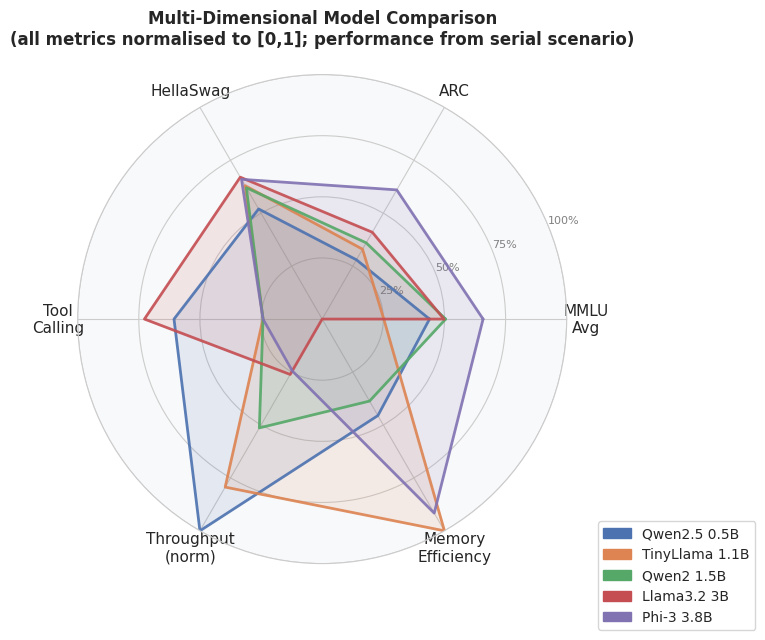

In [25]:
# 5.1  Fig combined_radar: Multi-dimensional radar chart
df_r = combined.copy()

# Throughput: higher = better; normalise to [0, 1]
if 'decode_speed_mean' in df_r.columns:
    vmax = df_r['decode_speed_mean'].max()
    df_r['throughput_norm'] = df_r['decode_speed_mean'] / vmax if vmax > 0 else 0.0
else:
    df_r['throughput_norm'] = np.nan

# Memory efficiency: lower RAM = better; min-max invert
if 'ram_peak_mean_gb' in df_r.columns:
    vmin_, vmax_ = df_r['ram_peak_mean_gb'].min(), df_r['ram_peak_mean_gb'].max()
    spread = vmax_ - vmin_
    if spread > 0:
        df_r['memory_eff'] = 1 - (df_r['ram_peak_mean_gb'] - vmin_) / spread
    else:
        df_r['memory_eff'] = 1.0   # all models identical RAM → full score
else:
    df_r['memory_eff'] = np.nan

dimensions = {
    'MMLU\nAvg':          'mmlu_avg',
    'ARC':                'arc',
    'HellaSwag':          'hellaswag',
    'Tool\nCalling':      'tool_overall',
    'Throughput\n(norm)': 'throughput_norm',
    'Memory\nEfficiency': 'memory_eff',
}
labels = list(dimensions.keys())
cols   = list(dimensions.values())
N      = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_facecolor('#f8f9fa')
for _, row in df_r.iterrows():
    model = row['model']
    if model not in PALETTE:
        continue
    vals = [float(row[c]) if c in row.index and not pd.isna(row[c]) else 0.0
            for c in cols]
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[model], linewidth=2, alpha=0.9)
    ax.fill(angles, vals, color=PALETTE[model], alpha=0.12)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=8, color='grey')
ax.set_title('Multi-Dimensional Model Comparison\n'
             '(all metrics normalised to [0,1]; performance from serial scenario)',
             fontsize=12, fontweight='bold', pad=22)
handles = [mpatches.Patch(color=PALETTE[m], label=m)
           for m in MODEL_ORDER if m in df_r['model'].values]
ax.legend(handles=handles, loc='lower right',
          bbox_to_anchor=(1.4, -0.15), fontsize=10)
plt.tight_layout()
savefig('combined_radar.png')
plt.show()

  Saved: combined_pareto.png


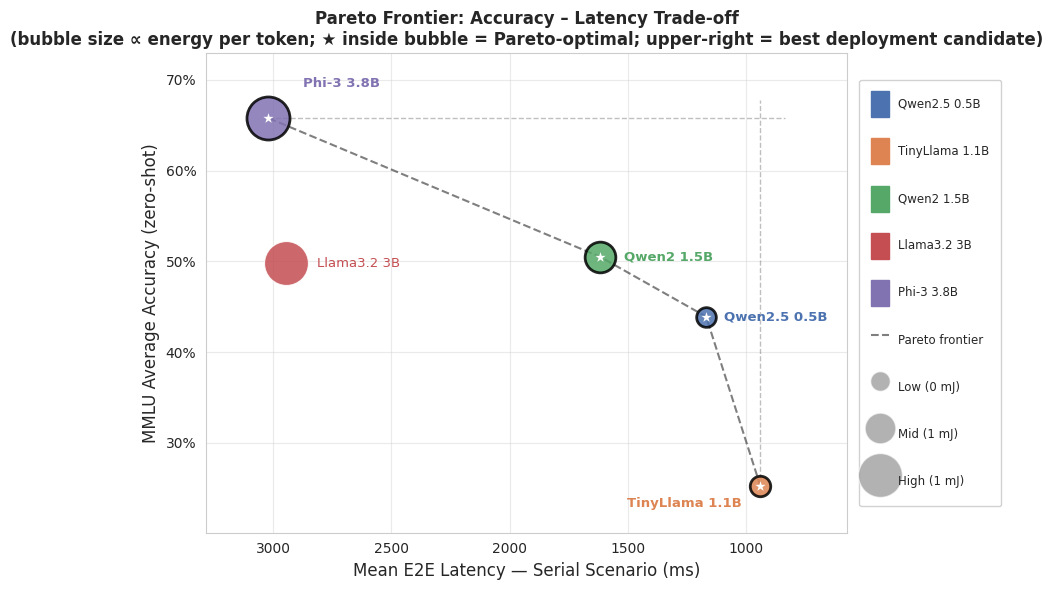

Pareto-optimal models: ['Qwen2.5 0.5B', 'TinyLlama 1.1B', 'Qwen2 1.5B', 'Phi-3 3.8B']


In [22]:
df_p = combined.dropna(subset=['mmlu_avg', 'latency_mean_ms']).copy()

# 用latency直接作为x轴（延迟越低越好，所以Pareto用负值判断）
pareto_models = []
for i, ri in df_p.iterrows():
    dominated = any(
        (rj['mmlu_avg']      >= ri['mmlu_avg']      and
         rj['latency_mean_ms'] <= ri['latency_mean_ms'] and
         (rj['mmlu_avg']      >  ri['mmlu_avg']      or
          rj['latency_mean_ms'] < ri['latency_mean_ms']))
        for j, rj in df_p.iterrows() if i != j
    )
    if not dominated:
        pareto_models.append(ri['model'])
df_p['on_pareto'] = df_p['model'].isin(pareto_models)

# 气泡大小 ∝ 能耗
if ('energy_per_tok_mean_j' in df_p.columns and
        df_p['energy_per_tok_mean_j'].fillna(0).sum() > 0):
    emax = df_p['energy_per_tok_mean_j'].max()
    emin = df_p['energy_per_tok_mean_j'].min()
    df_p['bubble_size'] = (
        (df_p['energy_per_tok_mean_j'] - emin) / (emax - emin)
    ) * 800 + 200
    size_note = 'bubble size ∝ energy per token; '
    has_energy = True
else:
    df_p['bubble_size'] = 400
    size_note = ''
    has_energy = False

# Pareto点按latency排序（从小到大）
pareto_pts = df_p[df_p['on_pareto']].sort_values('latency_mean_ms')

fig, ax = plt.subplots(figsize=(10, 6))

# 画气泡
for _, row in df_p.iterrows():
    color = PALETTE.get(row['model'], '#888')
    on    = row['on_pareto']
    ax.scatter(row['latency_mean_ms'], row['mmlu_avg'],
               s=row['bubble_size'],
               color=color, zorder=5,
               edgecolors='black' if on else 'white',
               linewidth=2.0 if on else 0.8,
               alpha=0.85)
    if on:
        ax.scatter(row['latency_mean_ms'], row['mmlu_avg'],
                   s=60, marker='*', color='white',
                   zorder=6, linewidth=0)

    # 标签位置
    bubble_r = (row['bubble_size'] ** 0.5) / 1.8
    if row['model'] == 'TinyLlama 1.1B':
        text_offset = (-bubble_r - 5, -15)
        ha_align = 'right'
    elif row['model'] == 'Phi-3 3.8B':
        text_offset = (bubble_r + 8, bubble_r + 5)
        ha_align = 'left'
    else:
        text_offset = (bubble_r + 5, -3)
        ha_align = 'left'
    ax.annotate(row['model'],
                (row['latency_mean_ms'], row['mmlu_avg']),
                textcoords='offset points',
                xytext=text_offset,
                ha=ha_align,
                fontsize=9.5, color=color,
                fontweight='bold' if on else 'normal')

# Pareto frontier线（latency越小越好，所以线从左上到右下）
legend1 = [mpatches.Patch(color=PALETTE[m], label=m)
           for m in MODEL_ORDER if m in df_p['model'].values]
legend2 = [plt.Line2D([0], [0], color='black', linestyle='--',
                       linewidth=1.5, alpha=0.5, label='Pareto frontier')]

if len(pareto_pts) >= 2:
    x_max, _ = ax.get_xlim()
    _, y_max  = ax.get_ylim()
    # 最左点（最快模型）向上延伸
    left_x  = pareto_pts['latency_mean_ms'].iloc[0]
    left_y  = pareto_pts['mmlu_avg'].iloc[0]
    # 最右点（最慢模型）向右延伸
    right_x = pareto_pts['latency_mean_ms'].iloc[-1]
    right_y = pareto_pts['mmlu_avg'].iloc[-1]

    ax.plot([left_x, left_x], [left_y, y_max],
            'k--', linewidth=1.0, alpha=0.25, zorder=1)
    ax.plot(pareto_pts['latency_mean_ms'], pareto_pts['mmlu_avg'],
            'k--', linewidth=1.5, alpha=0.5, zorder=1)
    ax.plot([right_x, x_max], [right_y, right_y],
            'k--', linewidth=1.0, alpha=0.25, zorder=1)

# 能耗图例
if has_energy:
    energy_vals = df_p['energy_per_tok_mean_j']
    for label, val in [
        (f'Low ({energy_vals.min():.0f} mJ)',    energy_vals.min()),
        (f'Mid ({energy_vals.median():.0f} mJ)', energy_vals.median()),
        (f'High ({energy_vals.max():.0f} mJ)',   energy_vals.max()),
    ]:
        size = ((val - emin) / (emax - emin)) * 800 + 200
        legend2.append(
            plt.scatter([], [], s=size, color='grey',
                        alpha=0.6, edgecolors='white', label=label)
        )

ax.set_xlabel('Mean E2E Latency — Serial Scenario (ms)', fontsize=12)
ax.invert_xaxis()
ax.set_ylabel('MMLU Average Accuracy (zero-shot)', fontsize=12)
ax.set_title(f'Pareto Frontier: Accuracy – Latency Trade-off\n'
             f'({size_note}★ inside bubble = Pareto-optimal; '
             f'upper-right = best deployment candidate)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(alpha=0.4)
ax.margins(0.12)

ax.legend(handles=legend1 + legend2, fontsize=8.5,
          loc='center left',
          bbox_to_anchor=(1.01, 0.5),
          ncol=1,
          frameon=True,
          framealpha=0.9,
          handlelength=1.5,
          handleheight=3.0,
          borderpad=1.0,
          labelspacing=1.8)

plt.tight_layout()
plt.subplots_adjust(right=0.72)
savefig('combined_pareto.png')
plt.show()
print(f'Pareto-optimal models: {pareto_models}')

  Saved: combined_pareto.png


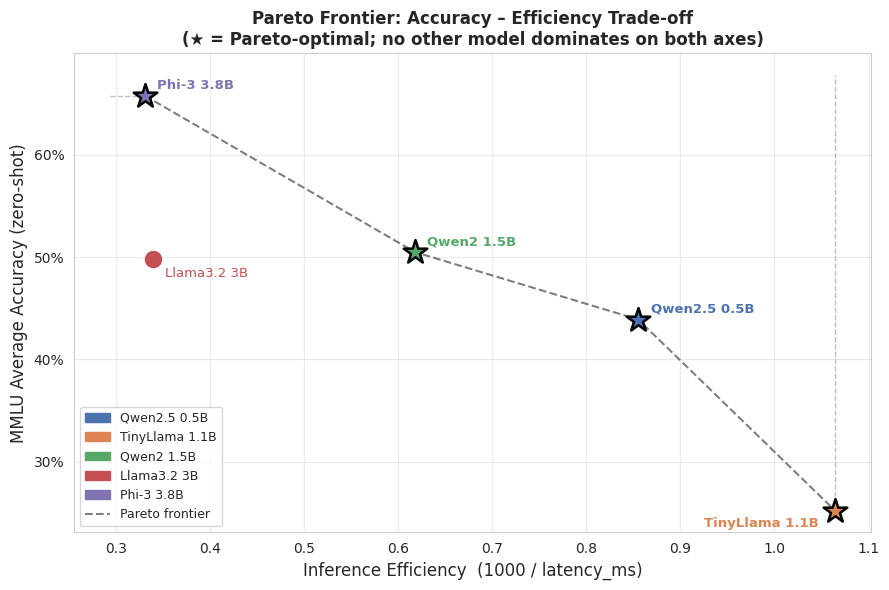


Pareto-optimal models: ['Qwen2.5 0.5B', 'TinyLlama 1.1B', 'Qwen2 1.5B', 'Phi-3 3.8B']


In [23]:
# 5.3  Fig combined_pareto: Pareto frontier with axis-boundary extensions
#      ax.plot() used (not step) to avoid spurious horizontal artefacts.
#      Single ax.legend() call merges model patches + frontier line handle.
df_p = combined.dropna(subset=['mmlu_avg', 'latency_mean_ms']).copy()
df_p['efficiency'] = 1000.0 / df_p['latency_mean_ms']

pareto_models = []
for i, ri in df_p.iterrows():
    dominated = any(
        (rj['mmlu_avg']   >= ri['mmlu_avg']   and
         rj['efficiency'] >= ri['efficiency'] and
         (rj['mmlu_avg']  >  ri['mmlu_avg']   or
          rj['efficiency'] > ri['efficiency']))
        for j, rj in df_p.iterrows() if i != j
    )
    if not dominated:
        pareto_models.append(ri['model'])

df_p['on_pareto'] = df_p['model'].isin(pareto_models)
pareto_pts = df_p[df_p['on_pareto']].sort_values('efficiency')

fig, ax = plt.subplots(figsize=(9, 6))

# Draw all model points first so xlim/ylim are stable before adding lines
for _, row in df_p.iterrows():
    color = PALETTE.get(row['model'], '#888')
    on    = row['on_pareto']
    ax.scatter(row['efficiency'], row['mmlu_avg'],
               s=320 if on else 180,
               marker='*' if on else 'o',
               color=color, zorder=5,
               edgecolors='black' if on else 'white',
               linewidth=1.8 if on else 0.8)

    # 【修改点 1】：专门把 TinyLlama 的名字往左边拉，防止超出画框右侧
    if row['model'] == 'TinyLlama 1.1B':
        text_offset = (-12, -12)
        ha_align = 'right'
    else:
        text_offset = (9, 5 if on else -13)
        ha_align = 'left'

    ax.annotate(row['model'],
                (row['efficiency'], row['mmlu_avg']),
                textcoords='offset points',
                xytext=text_offset,
                ha=ha_align,
                fontsize=9.5, color=color,
                fontweight='bold' if on else 'normal')

# Build legend: model patches first, frontier line appended once at the end
handles = [mpatches.Patch(color=PALETTE[m], label=m)
           for m in MODEL_ORDER if m in df_p['model'].values]

if len(pareto_pts) >= 2:
    x_min, _ = ax.get_xlim()
    _, y_max  = ax.get_ylim()
    left_x,  left_y  = pareto_pts['efficiency'].iloc[0],  pareto_pts['mmlu_avg'].iloc[0]
    right_x, right_y = pareto_pts['efficiency'].iloc[-1], pareto_pts['mmlu_avg'].iloc[-1]

    # Left ghost extension: horizontal to axis edge
    ax.plot([x_min, left_x], [left_y, left_y],
            'k--', linewidth=1.0, alpha=0.25, zorder=1)
    # Main Pareto frontier line
    ax.plot(pareto_pts['efficiency'], pareto_pts['mmlu_avg'],
            'k--', linewidth=1.5, alpha=0.5, zorder=1)
    # Right ghost extension: vertical to top
    ax.plot([right_x, right_x], [right_y, y_max],
            'k--', linewidth=1.0, alpha=0.25, zorder=1)

    # Append frontier to handles — single legend call, no duplication
    handles.append(plt.Line2D([0], [0], color='black', linestyle='--',
                               linewidth=1.5, alpha=0.5, label='Pareto frontier'))

elif len(pareto_pts) == 1:
    ax.plot(pareto_pts['efficiency'].iloc[0],
            pareto_pts['mmlu_avg'].iloc[0],
            'k*', markersize=20, alpha=0.5, zorder=1)

ax.set_xlabel('Inference Efficiency  (1000 / latency_ms)', fontsize=12)
ax.set_ylabel('MMLU Average Accuracy (zero-shot)', fontsize=12)
ax.set_title('Pareto Frontier: Accuracy – Efficiency Trade-off\n'
             '(★ = Pareto-optimal; no other model dominates on both axes)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(alpha=0.4)

# 【修改点 2】：图表边缘留出 5% 的空白余量，防止星号贴边
ax.margins(0.05)

# 【修改点 3】：将图例移动到左下角的空旷区 (lower left)
ax.legend(handles=handles, fontsize=9, loc='lower left')

plt.tight_layout()
savefig('combined_pareto.png')
plt.show()
print(f'\nPareto-optimal models: {pareto_models}')

## 6. Export Summary

In [24]:
# 6.1  Save combined_summary.csv and validate all output files
out_csv = os.path.join(BASE, 'results', 'combined_summary.csv')
combined.to_csv(out_csv, index=False)
print(f'combined_summary.csv   →  {os.path.abspath(out_csv)}')

stat_csv = os.path.join(BASE, 'results', 'statistical_tests.csv')
if os.path.exists(stat_csv):
    print(f'statistical_tests.csv  →  {os.path.abspath(stat_csv)}')
else:
    print('[WARNING] statistical_tests.csv not found — run Section 3 first')

figs = sorted(os.listdir(FIGURES_DIR))
print(f'\nGenerated {len(figs)} figures:')
for f in figs:
    print(f'  {f}')

combined_summary.csv   →  E:\DATA\gx498\Desktop\course work\8099\results\combined_summary.csv
statistical_tests.csv  →  E:\DATA\gx498\Desktop\course work\8099\results\statistical_tests.csv

Generated 13 figures:
  cap_01_overview.png
  cap_02_mmlu_heatmap.png
  combined_pareto.png
  combined_radar.png
  perf_01_latency.png
  perf_02_distribution.png
  perf_03_07_panel.png
  perf_08_degradation.png
  perf_09_percentiles.png
  perf_10_cold_start.png
  perf_11_concurrency_penalty.png
  tool_01_heatmap.png
  tool_02_overview.png
